In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [3]:
cancer=load_breast_cancer()
X_train,X_test,y_train,y_test=train_test_split(cancer.data,cancer.target,stratify=cancer.target,random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(solver='liblinear').fit(X_train,y_train)

In [10]:
print(logreg.score(X_train,y_train))
print(logreg.score(X_test,y_test))

0.9530516431924883
0.958041958041958


In [15]:
logreg100=LogisticRegression(C=100,solver='liblinear').fit(X_train,y_train)
print(logreg100.score(X_train,y_train))
print(logreg100.score(X_test,y_test))

0.9765258215962441
0.965034965034965


In [16]:
logreg001=LogisticRegression(C=0.01,solver='liblinear').fit(X_train,y_train)
print(logreg001.score(X_train,y_train))
print(logreg001.score(X_test,y_test))

0.9342723004694836
0.9300699300699301


In [28]:
for C, market in zip([0.001,1,100,1000],['-','--','-.',':']):
  lr_l1=LogisticRegression(C=C,penalty='l1',max_iter=1000,solver='liblinear').fit(X_train,y_train)
  train_acc = lr_l1.score(X_train, y_train)
  test_acc = lr_l1.score(X_test, y_test)
  print(f"C = {C:<8} Train: {train_acc:.2f}   Test: {test_acc:.2f}")

C = 0.001    Train: 0.91   Test: 0.92
C = 1        Train: 0.96   Test: 0.96
C = 100      Train: 0.99   Test: 0.98
C = 1000     Train: 1.00   Test: 0.94


In [33]:
from sklearn.datasets import make_blobs
!pip install mglearn
import mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 5.7 MB/s eta 0:00:00


Text(0, 0.5, 'Feature 1')

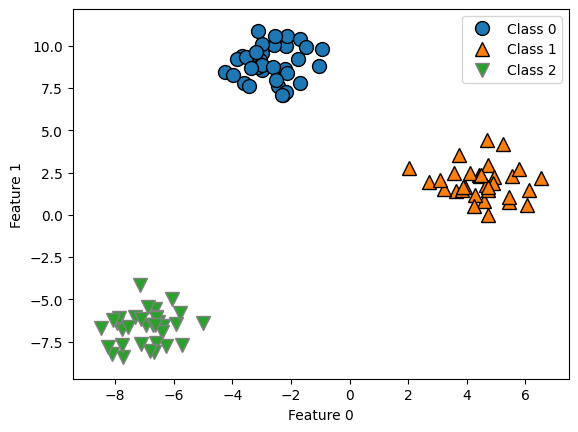

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline
X,y=make_blobs(random_state=42)
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.legend(['Class 0','Class 1','Class 2'])
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

In [41]:
from sklearn.svm import LinearSVC
linear_svm=LinearSVC().fit(X,y)
print(linear_svm.coef_)
print(linear_svm.intercept_)

[[-0.17492412  0.23140766]
 [ 0.47622012 -0.06936786]
 [-0.18914207 -0.20400079]]
[-1.07745775  0.13139239 -0.08604962]


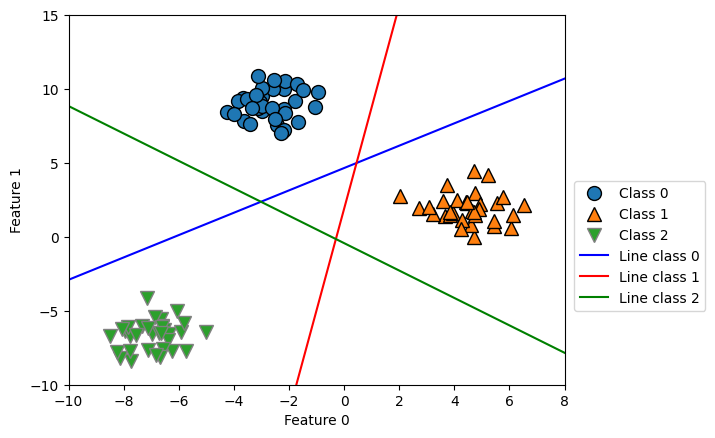

In [43]:
import numpy as np
mglearn.discrete_scatter(X[:,0],X[:,1],y)
np.random.seed(0)
line=np.linspace(-15,15)
for coef,intercept,color in zip(linear_svm.coef_,linear_svm.intercept_,['b','r','g']):
  plt.plot(line,-(line*coef[0]+intercept)/coef[1],c=color)
  plt.ylim(-10,15)
  plt.xlim(-10,8)
  plt.xlabel('Feature 0')
  plt.ylabel('Feature 1')
  plt.legend(['Class 0','Class 1','Class 2','Line class 0','Line class 1','Line class 2'], loc=(1.02,0.2))